# Durak Autoresearch Experiment Analysis

Analysis of autonomous heuristic-search results from `results.tsv` — the Durak
local-heuristics vs memory-baseline loop (`program.md`).

**Run:** execute all cells in this notebook, or from the repo root:

```bash
jupyter nbconvert --execute analysis.ipynb
```

Writes `progress.png` (point_rate + search_score over time) and `occam.png`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

RESULTS_PATH = Path("results.tsv")
if not RESULTS_PATH.exists():
    raise FileNotFoundError(
        "results.tsv not found. Run the autoresearch loop first (see program.md)."
    )

# Durak schema: commit, opponent, point_rate, search_score, lower_ci, games, complexity, status, description
df = pd.read_csv(RESULTS_PATH, sep="\t", dtype=str)
for col in ("point_rate", "search_score", "lower_ci", "games", "complexity"):
    df[col] = pd.to_numeric(df[col], errors="coerce")
df["status"] = df["status"].str.strip().str.lower()
df["opponent"] = df["opponent"].str.strip()
df["commit"] = df["commit"].str.strip()

# Headline rows: B2 vs B4 (one ladder eval per commit / probe)
b4 = df[df["opponent"] == "B4"].copy().reset_index(drop=True)
b4["exp_id"] = np.arange(len(b4))

print(f"Total rows: {len(df)}  |  B4 headline rows: {len(b4)}")
print(f"Columns: {list(df.columns)}")
b4.head(10)

Total rows: 32  |  B4 headline rows: 21
Columns: ['commit', 'opponent', 'point_rate', 'search_score', 'lower_ci', 'games', 'complexity', 'status', 'description']


,commit,opponent,point_rate,search_score,lower_ci,games,complexity,status,description,exp_id
0,228791f,B4,0.49211,0.68404,0.49200,10000000,310,keep,"baseline B2 H1-H3 (min non-trump, low group, s...",0
1,2415f53,B4,0.50461,0.70002,0.50447,10000000,210,keep,exp A: drop H3 (same-rank trump defense was wa...,1
2,35330ec,B4,0.52434,0.72562,0.52409,10000000,100,keep,exp B: drop H2 + kDelta throw-in cap (H1-only)...,2
3,probe,B4,0.06956,0.25076,0.06845,200000,200,discard,probe C1: endgame take-instead-of-trump is cat...,3
4,probe,B4,0.52873,0.72876,0.52698,200000,200,discard,probe C2: endgame pair-pressure; real but smal...,4
5,probe,B4,0.52507,0.72626,0.52331,200000,100,discard,probe C3: feasibility-aware take (bipartite ma...,5
6,probe,B4,0.52404,0.72562,0.52228,200000,200,discard,"probe C4: endgame trump-strip (deck0, opp<=4, ...",6
7,probe,B4,0.52464,0.71671,0.52290,200000,200,discard,probe D1: voluntary take high trump (H2); tiny...,7
8,probe,B4,0.52481,0.72608,0.52306,200000,100,discard,probe D2: stop pile-on when opp<=2; neutral wi...,8
9,probe,B4,0.52484,0.71599,0.52309,200000,200,discard,probe D5: longest suit at min rank opening (H2...,9


In [2]:
counts = b4["status"].value_counts()
print("B4 headline experiment outcomes:")
print(counts.to_string())

n_keep = int(counts.get("keep", 0))
n_discard = int(counts.get("discard", 0))
n_crash = int(counts.get("crash", 0))
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

# Ablation rows (if any)
ablate = df[df["opponent"] == "B3vsB2"]
if len(ablate):
    print("\nMemory ablation (B3 vs B2):")
    for _, row in ablate.iterrows():
        print(
            f"  {row['commit']}  point_rate={float(row['point_rate']):.5f}  "
            f"memory_value≈{float(row['point_rate']) - 0.5:.5f}  {row['description']}"
        )

B4 headline experiment outcomes:
status
discard    17
keep        4

Keep rate: 4/21 = 19.0%

Memory ablation (B3 vs B2):
  228791f  point_rate=0.50000  memory_value≈0.00000  memory ablation; memory hook inert for v1 heuristics (tied cards share rank) so memory value = 0
  35330ec  point_rate=0.50000  memory_value≈0.00000  final ablation: memory value = 0 (B3==B2 exactly, split=1.0); unknown-rank tie-break is degenerate within a rank
  c263a3a  point_rate=0.50000  memory_value≈0.00000  ablation after G: memory still inert (split=1.0)


In [3]:
kept = b4[b4["status"] == "keep"].copy()
print(f"KEPT B4 experiments ({len(kept)} total):\n")
for _, row in kept.iterrows():
  print(
      f"  {row['commit']}  point_rate={row['point_rate']:.5f}  "
      f"search={row['search_score']:.5f}  complexity={int(row['complexity'])}  "
      f"{row['description']}"
  )

KEPT B4 experiments (4 total):

  228791f  point_rate=0.49211  search=0.68404  complexity=310  baseline B2 H1-H3 (min non-trump, low group, same-rank trump defense) vs memory baseline
  2415f53  point_rate=0.50461  search=0.70002  complexity=210  exp A: drop H3 (same-rank trump defense was wasting higher trumps); B2 now beats B4, CI fully above 0.50
  35330ec  point_rate=0.52434  search=0.72562  complexity=100  exp B: drop H2 + kDelta throw-in cap (H1-only); DOMINATES B4 (lower_ci 0.5241 > 0.52); aggressive pile-on
  c263a3a  point_rate=0.53748  search=0.73239  complexity=100  exp G: endgame open low pair when min non-trump is singleton; B4 +0.013, search +0.007


## Point rate vs B4 (reporting metric)

Track how `point_rate(B2 vs B4)` and `search_score` evolve. Higher is better.
The running maximum shows the frontier — best result achieved so far.

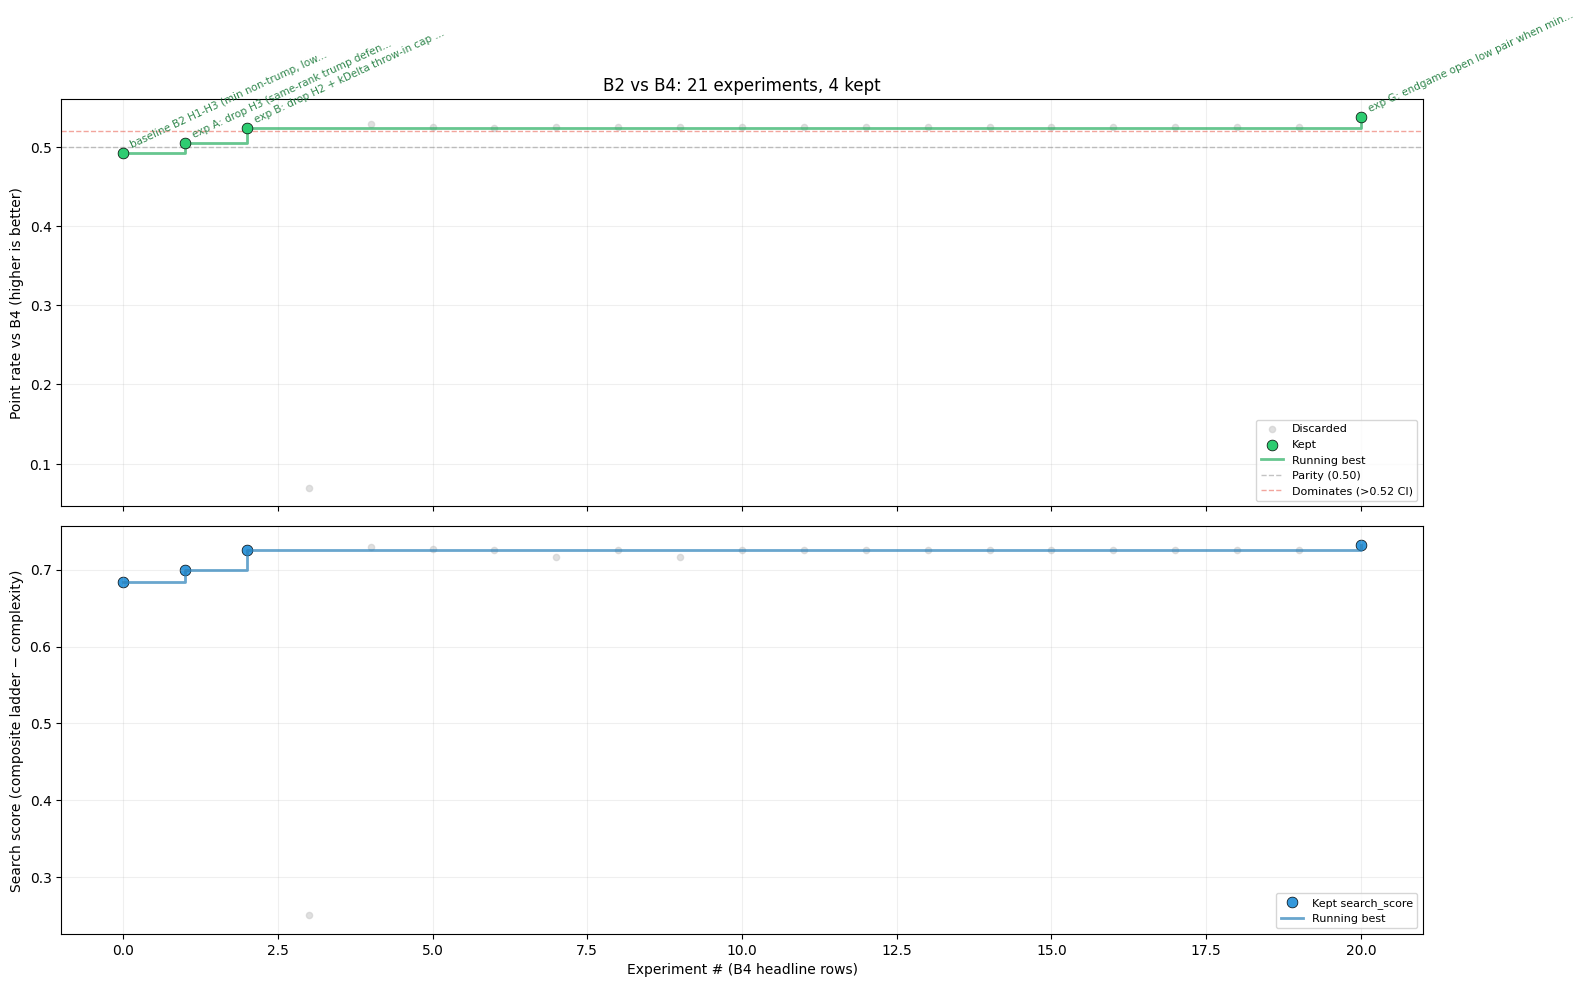

Saved to progress.png


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

valid = b4[b4["status"] != "crash"].copy()

# --- Top: point_rate vs B4 ---
ax = axes[0]
disc = valid[valid["status"] == "discard"]
ax.scatter(disc["exp_id"], disc["point_rate"], c="#cccccc", s=20, alpha=0.6, label="Discarded")
kept_v = valid[valid["status"] == "keep"]
ax.scatter(
    kept_v["exp_id"], kept_v["point_rate"], c="#2ecc71", s=60, zorder=4,
    label="Kept", edgecolors="black", linewidths=0.5,
)
if len(kept_v):
    running_max = kept_v["point_rate"].cummax()
    ax.step(kept_v["exp_id"], running_max, where="post", color="#27ae60",
            linewidth=2, alpha=0.7, label="Running best")
    for _, row in kept_v.iterrows():
        desc = str(row["description"]).strip()
        if len(desc) > 40:
            desc = desc[:37] + "..."
        ax.annotate(desc, (row["exp_id"], row["point_rate"]),
                    textcoords="offset points", xytext=(4, 4), fontsize=7.5,
                    color="#1a7a3a", alpha=0.9, rotation=25, ha="left")
ax.axhline(0.50, color="#888", linestyle="--", linewidth=1, alpha=0.5, label="Parity (0.50)")
ax.axhline(0.52, color="#e74c3c", linestyle="--", linewidth=1, alpha=0.5, label="Dominates (>0.52 CI)")
ax.set_ylabel("Point rate vs B4 (higher is better)")
ax.legend(loc="lower right", fontsize=8)
ax.grid(True, alpha=0.2)
ax.set_title(f"B2 vs B4: {len(b4)} experiments, {len(kept_v)} kept")

# --- Bottom: search_score ---
ax2 = axes[1]
ax2.scatter(disc["exp_id"], disc["search_score"], c="#cccccc", s=20, alpha=0.6)
ax2.scatter(kept_v["exp_id"], kept_v["search_score"], c="#3498db", s=60,
            edgecolors="black", linewidths=0.5, label="Kept search_score")
if len(kept_v):
    ax2.step(kept_v["exp_id"], kept_v["search_score"].cummax(), where="post",
             color="#2980b9", linewidth=2, alpha=0.7, label="Running best")
ax2.set_xlabel("Experiment # (B4 headline rows)")
ax2.set_ylabel("Search score (composite ladder − complexity)")
ax2.legend(loc="lower right", fontsize=8)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary statistics

In [5]:
kept_b4 = b4[b4["status"] == "keep"].copy()
if len(b4) == 0:
    print("No B4 rows yet.")
else:
    baseline_pr = float(b4.iloc[0]["point_rate"])
    baseline_search = float(b4.iloc[0]["search_score"])
    best_pr = float(kept_b4["point_rate"].max()) if len(kept_b4) else baseline_pr
    best_search = float(kept_b4["search_score"].max()) if len(kept_b4) else baseline_search
    best_row = kept_b4.loc[kept_b4["point_rate"].idxmax()] if len(kept_b4) else b4.iloc[0]

    print(f"Baseline point_rate vs B4:  {baseline_pr:.5f}")
    print(f"Best point_rate vs B4:      {best_pr:.5f}  (Δ {best_pr - baseline_pr:+.5f})")
    print(f"Baseline search_score:      {baseline_search:.5f}")
    print(f"Best search_score:          {best_search:.5f}  (Δ {best_search - baseline_search:+.5f})")
    print(f"Best experiment:            {best_row['description']}")
    print(f"Best complexity:            {int(best_row['complexity'])}")
    print()

    # Ladder at best kept commit
    best_commit = best_row["commit"]
    ladder = df[df["commit"] == best_commit]
    print(f"Ladder at best commit {best_commit}:")
    for opp in ["B4", "B1", "B0", "B3vsB2"]:
        rows = ladder[ladder["opponent"] == opp]
        if len(rows):
            r = rows.iloc[0]
            print(f"  vs {opp:6s}  point_rate={float(r['point_rate']):.5f}  lower_ci={float(r['lower_ci']):.5f}")

Baseline point_rate vs B4:  0.49211
Best point_rate vs B4:      0.53748  (Δ +0.04537)
Baseline search_score:      0.68404
Best search_score:          0.73239  (Δ +0.04835)
Best experiment:            exp G: endgame open low pair when min non-trump is singleton; B4 +0.013, search +0.007
Best complexity:            100

Ladder at best commit c263a3a:
  vs B4      point_rate=0.53748  lower_ci=0.53723
  vs B1      point_rate=0.93277  lower_ci=0.93262
  vs B0      point_rate=0.96913  lower_ci=0.96903
  vs B3vsB2  point_rate=0.50000  lower_ci=0.50000


## Top hits (kept experiments by improvement vs previous keep)

In [6]:
kept_b4 = b4[b4["status"] == "keep"].copy()
if len(kept_b4) < 2:
    print("Need at least 2 kept experiments for deltas.")
else:
    kept_b4 = kept_b4.copy()
    kept_b4["prev_pr"] = kept_b4["point_rate"].shift(1)
    kept_b4["delta_pr"] = kept_b4["point_rate"] - kept_b4["prev_pr"]
    hits = kept_b4.iloc[1:].sort_values("delta_pr", ascending=False)

    print(f"{'Rank':>4}  {'Δ point_rate':>12}  {'point_rate':>10}  {'search':>8}  {'complexity':>10}  Description")
    print("-" * 100)
    for rank, (_, row) in enumerate(hits.iterrows(), 1):
        print(
            f"{rank:4d}  {row['delta_pr']:+.5f}      {row['point_rate']:.5f}  "
            f"{row['search_score']:.5f}  {int(row['complexity']):10d}  {row['description']}"
        )
    print(f"\n{'':>4}  {hits['delta_pr'].sum():+.5f}      {'':>10}  {'':>8}  TOTAL vs baseline keep")

Rank  Δ point_rate  point_rate    search  complexity  Description
----------------------------------------------------------------------------------------------------
   1  +0.01973      0.52434  0.72562         100  exp B: drop H2 + kDelta throw-in cap (H1-only); DOMINATES B4 (lower_ci 0.5241 > 0.52); aggressive pile-on
   2  +0.01314      0.53748  0.73239         100  exp G: endgame open low pair when min non-trump is singleton; B4 +0.013, search +0.007
   3  +0.01250      0.50461  0.70002         210  exp A: drop H3 (same-rank trump defense was wasting higher trumps); B2 now beats B4, CI fully above 0.50

      +0.04537                            TOTAL vs baseline keep


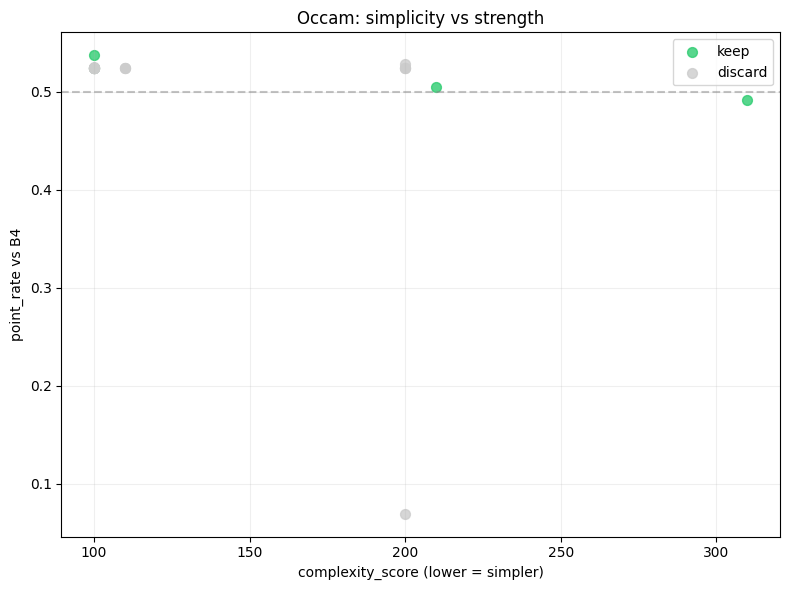

Saved to occam.png


In [7]:
# Complexity vs point_rate (Occam view): did simplification help?
fig, ax = plt.subplots(figsize=(8, 6))
for status, color, label in [
    ("keep", "#2ecc71", "keep"),
    ("discard", "#cccccc", "discard"),
]:
    sub = b4[b4["status"] == status]
    ax.scatter(sub["complexity"], sub["point_rate"], c=color, s=50, alpha=0.8, label=label)
ax.set_xlabel("complexity_score (lower = simpler)")
ax.set_ylabel("point_rate vs B4")
ax.set_title("Occam: simplicity vs strength")
ax.axhline(0.50, color="#888", linestyle="--", alpha=0.5)
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("occam.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to occam.png")